# Lab 4 — KNN Classification & Regression vs Classification Metrics
**Dataset:** Breast Cancer Wisconsin (Diagnostic) — 569 samples, 30 features
**Target:** `0 = Malignant`, `1 = Benign`

**Name:** Reno Reji Matthew
**Class:** 4 MCA A
**Roll No.:** 2547145



In [1]:
# Setup — run this first
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report, roc_curve, auc,
                             mean_absolute_error, mean_squared_error, r2_score)
RANDOM_STATE = 42

## Task 1 — Data Preparation

**Why feature scaling matters for KNN.** KNN classifies a point by looking at the
*distances* to its neighbours. Distance is dominated by features with large numeric
ranges. In this dataset `area` is in the hundreds while `smoothness` is ~0.1 — without
scaling, `area` alone would decide almost every neighbour. `StandardScaler` transforms
each feature to **mean 0, std 1** (z-score), so every feature contributes fairly to the
distance. Scaling is *essential* for any distance-based algorithm (KNN, K-Means, SVM-RBF).


In [2]:
# Load dataset and build a DataFrame
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")   # 0 = malignant, 1 = benign

print("Shape:", X.shape)
X.head()

Shape: (569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Structure, missing values, duplicates
print("Missing values (total):", X.isnull().sum().sum())
print("Duplicate rows:", X.duplicated().sum())
print("\nClass balance (0=malignant, 1=benign):")
print(y.value_counts())
X.describe().T[["mean", "std", "min", "max"]].head(6)

Missing values (total): 0
Duplicate rows: 0

Class balance (0=malignant, 1=benign):
target
1    357
0    212
Name: count, dtype: int64


,mean,std,min,max
mean radius,14.127292,3.524049,6.98100,28.1100
mean texture,19.289649,4.301036,9.71000,39.2800
mean perimeter,91.969033,24.298981,43.79000,188.5000
mean area,654.889104,351.914129,143.50000,2501.0000
mean smoothness,0.096360,0.014064,0.05263,0.1634
mean compactness,0.104341,0.052813,0.01938,0.3454


In [4]:
# Feature scaling (z-score standardisation)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("After scaling -> mean:", round(X_scaled.mean(), 6), "| std:", round(X_scaled.std(), 4))

After scaling -> mean: -0.0 | std: 1.0


## Task 2 — Train-Test Split Analysis

We compare **80:20**, **70:30** and **90:10** splits (all *stratified* so class ratios are
preserved). Larger training sets usually generalise better, but a smaller test set gives a
**noisier, less reliable** accuracy estimate — a single lucky/unlucky test point swings the
number a lot. That instability is exactly why we later move to cross-validation.


In [5]:
k_demo = 5   # fixed K just to compare splits fairly
rows = []
for test_size, label in [(0.20, "80:20"), (0.30, "70:30"), (0.10, "90:10")]:
    Xtr, Xte, ytr, yte = train_test_split(X_scaled, y, test_size=test_size,
                                          random_state=RANDOM_STATE, stratify=y)
    model = KNeighborsClassifier(n_neighbors=k_demo).fit(Xtr, ytr)
    acc = accuracy_score(yte, model.predict(Xte))
    rows.append([label, len(Xtr), len(Xte), round(acc, 4)])

pd.DataFrame(rows, columns=["Split", "Train size", "Test size", "Accuracy"])

,Split,Train size,Test size,Accuracy
0,80:20,455,114,0.9649
1,70:30,398,171,0.9708
2,90:10,512,57,0.9825


In [6]:
# Fix the 80:20 split for all remaining tasks
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)
print("Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Train: 455 | Test: 114


## Task 3 — KNN with Heuristic K Selection

### 3.1 Heuristic rule: K = √n
A common rule of thumb sets K to the square root of the number of training samples.
It gives a sensible **starting point** that balances noise (too-small K) against
over-smoothing (too-large K). We nudge it to the nearest **odd** number so a binary
vote can never tie.


In [7]:
n = len(X_train)
k_heuristic = int(np.sqrt(n))
if k_heuristic % 2 == 0:        # prefer odd K to avoid ties in binary voting
    k_heuristic += 1
print(f"n_train = {n}  ->  sqrt(n) = {np.sqrt(n):.2f}  ->  heuristic K = {k_heuristic}")

n_train = 455  ->  sqrt(n) = 21.33  ->  heuristic K = 21


### 3.2 Model training — sweep K ± 5 and plot accuracy vs K

Best K on test set: 18 | accuracy: 0.9825


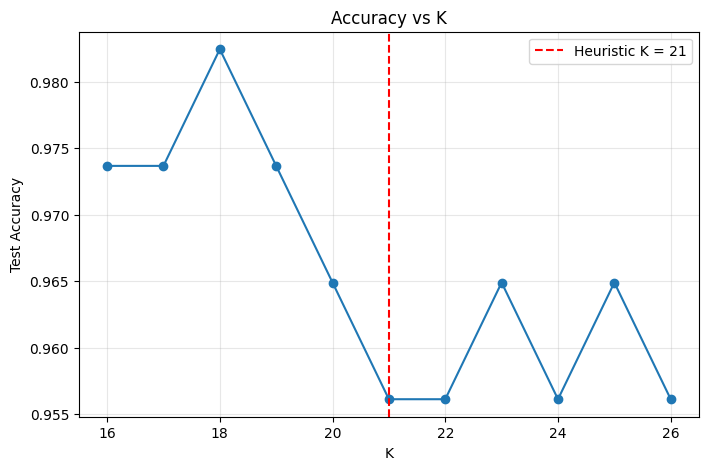

In [8]:
k_values = list(range(max(1, k_heuristic - 5), k_heuristic + 6))
accuracies = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k).fit(X_train, y_train)
    accuracies.append(accuracy_score(y_test, model.predict(X_test)))

best_k_tts = k_values[int(np.argmax(accuracies))]
print("Best K on test set:", best_k_tts, "| accuracy:", round(max(accuracies), 4))

plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker="o")
plt.axvline(k_heuristic, color="red", ls="--", label=f"Heuristic K = {k_heuristic}")
plt.xlabel("K"); plt.ylabel("Test Accuracy"); plt.title("Accuracy vs K")
plt.legend(); plt.grid(alpha=0.3); plt.show()

### 3.3 Distance metrics & decision boundaries

**Euclidean distance** (L2) — straight-line distance, `sqrt(Σ(a−b)²)`. Best when features
are continuous and on a comparable scale (our case, after scaling). It is the default in
scikit-learn's KNN.

**Manhattan distance** (L1) — sum of absolute differences, `Σ|a−b|`. More robust to
outliers and often preferred in **high-dimensional** or grid-like/sparse data, because L2
distances tend to "concentrate" (all points look equally far) as dimensions grow.

Rule of thumb: *Euclidean* for low-dimensional, smooth, scaled continuous data; *Manhattan*
when there are many dimensions or heavy outliers.

**Decision boundaries.** KNN has no equation for its boundary — it is implied by the
training points. To *see* it we project the 30 features to **2D with PCA** and train KNN
there. Watch how the boundary changes with K:
- **K = 1** → very jagged, wraps around single points → **overfits** (high variance).
- **K = 20** → smooth, general boundary → **underfits** if pushed too far (high bias).


In [9]:
# Two distance metrics compared at the heuristic K
for metric in ["euclidean", "manhattan"]:
    m = KNeighborsClassifier(n_neighbors=k_heuristic, metric=metric).fit(X_train, y_train)
    print(f"{metric:>10} distance -> accuracy: {accuracy_score(y_test, m.predict(X_test)):.4f}")

 euclidean distance -> accuracy: 0.9561
 manhattan distance -> accuracy: 0.9474


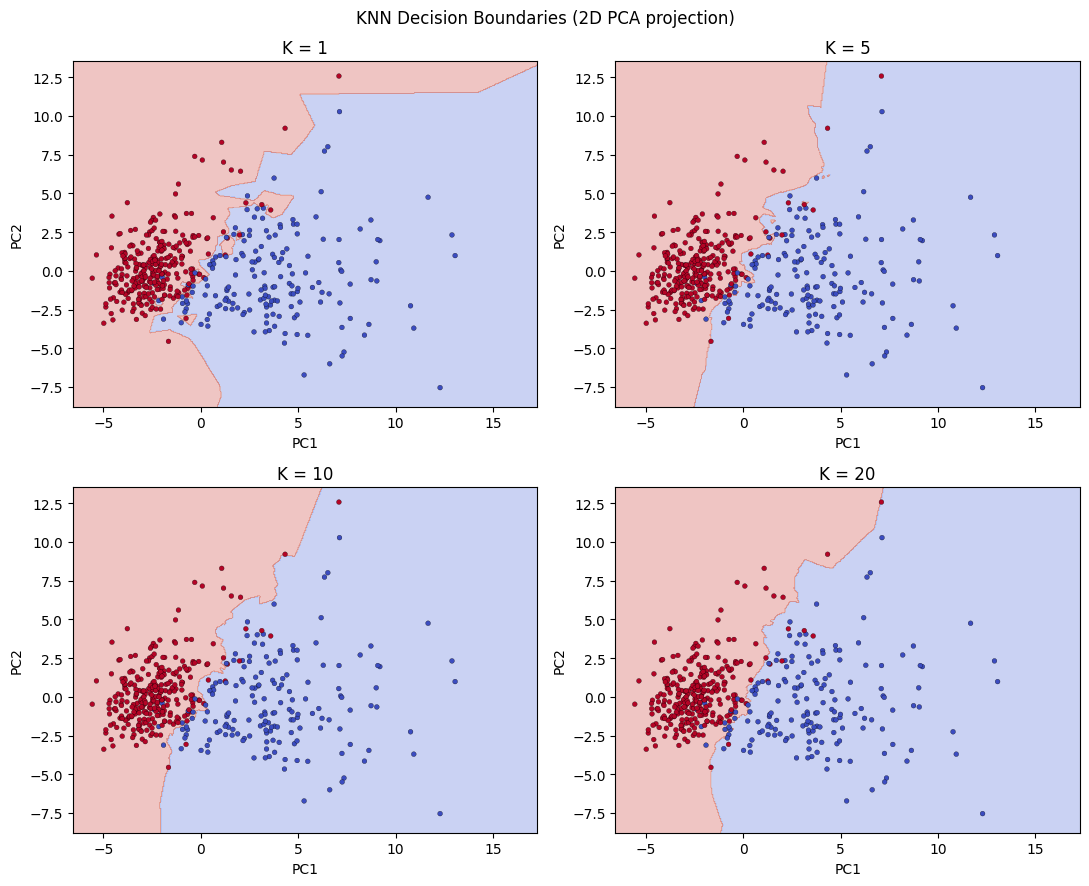

Variance captured by 2 PCA components: 0.632


In [10]:
# Decision boundaries on a 2D PCA projection for K = 1, 5, 10, 20
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X2 = pca.fit_transform(X_scaled)
X2_tr, X2_te, y2_tr, y2_te = train_test_split(
    X2, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

h = 0.05
x_min, x_max = X2[:, 0].min() - 1, X2[:, 0].max() + 1
y_min, y_max = X2[:, 1].min() - 1, X2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
for ax, k in zip(axes.ravel(), [1, 5, 10, 20]):
    clf = KNeighborsClassifier(n_neighbors=k).fit(X2_tr, y2_tr)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
    ax.scatter(X2_tr[:, 0], X2_tr[:, 1], c=y2_tr, cmap="coolwarm",
               s=12, edgecolor="k", linewidth=0.2)
    ax.set_title(f"K = {k}"); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
plt.suptitle("KNN Decision Boundaries (2D PCA projection)")
plt.tight_layout(); plt.show()

print("Variance captured by 2 PCA components:",
      round(pca.explained_variance_ratio_.sum(), 3))

## Task 4 — K-Fold Cross Validation

A single train-test split judges the model on **one** test set. **10-fold CV** splits the
data into 10 parts, trains on 9 and tests on the held-out 1, rotating through all 10 — so
*every* sample is used for testing exactly once. The mean accuracy is far more **reliable**,
and the std tells us how stable the model is. We pick our final K using CV, not the single
split.


In [11]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
rows = []
for k in k_values:
    scores = cross_val_score(KNeighborsClassifier(n_neighbors=k),
                             X_scaled, y, cv=cv, scoring="accuracy")
    rows.append([k, round(scores.mean(), 4), round(scores.std(), 4)])

cv_df = pd.DataFrame(rows, columns=["K", "CV mean accuracy", "CV std"])
best_k_cv = int(cv_df.loc[cv_df["CV mean accuracy"].idxmax(), "K"])
print("Best K by 10-fold CV:", best_k_cv)
cv_df

Best K by 10-fold CV: 16


,K,CV mean accuracy,CV std
0,16,0.9631,0.0241
1,17,0.9596,0.0208
2,18,0.9596,0.0222
3,19,0.9578,0.0250
4,20,0.9596,0.0272
5,21,0.9526,0.0248
6,22,0.9543,0.0238
7,23,0.9543,0.0262
8,24,0.9543,0.0262
9,25,0.9543,0.0262


**Selecting the final K.** The heuristic (√n) gave a baseline. The single-split sweep
and the 10-fold CV both point to a K in the same neighbourhood. We take the CV winner as the
final K because CV is the most trustworthy estimate.

## Task 5 — Classification Evaluation

We report **Accuracy, Precision, Recall, F1, Confusion Matrix and ROC-AUC**.

For cancer screening the clinically important class is **malignant**. A *false negative*
(a malignant tumour predicted benign) is the dangerous error, so **Recall** on malignant
cases matters most. We compute the ROC curve treating **malignant as the positive class**.


In [12]:
final_k = best_k_cv
final_model = KNeighborsClassifier(n_neighbors=final_k).fit(X_train, y_train)
y_pred = final_model.predict(X_test)

print(f"Final K = {final_k}\n")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall   :", round(recall_score(y_test, y_pred), 4))
print("F1 Score :", round(f1_score(y_test, y_pred), 4))
print("\nClassification report:\n", classification_report(y_test, y_pred,
      target_names=data.target_names))

Final K = 16

Accuracy : 0.9737
Precision: 0.9726
Recall   : 0.9861
F1 Score : 0.9793

Classification report:
               precision    recall  f1-score   support

   malignant       0.98      0.95      0.96        42
      benign       0.97      0.99      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



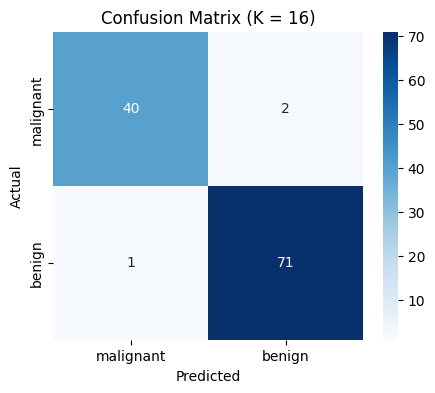

In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title(f"Confusion Matrix (K = {final_k})"); plt.show()

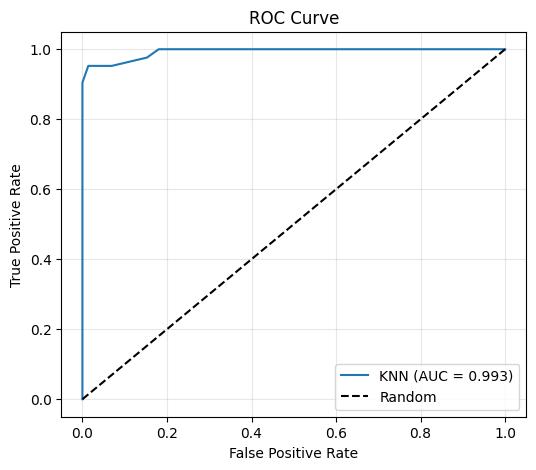

ROC-AUC: 0.9931


In [14]:
# ROC curve & AUC — malignant (label 0) treated as the positive class
y_test_malignant = (y_test == 0).astype(int)
proba_malignant  = final_model.predict_proba(X_test)[:, 0]

fpr, tpr, _ = roc_curve(y_test_malignant, proba_malignant)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"KNN (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve"); plt.legend(); plt.grid(alpha=0.3); plt.show()
print("ROC-AUC:", round(roc_auc, 4))

## Task 6 — Comparative Study with Regression (Lab 3 Integration)

In **Lab 3**, we studied **Linear Regression** on two datasets:

1. **Student Survey dataset** (`2547145_Lab3.ipynb`) — A simple linear regression predicting
   GPA from CIA percentage and Attendance percentage.
2. **Auto MPG dataset** (`Lab3_AutoMPG_Linear_Regression.ipynb`) — A multiple linear regression
   predicting fuel efficiency (mpg) from features like displacement, horsepower, weight, etc.

Both regression labs were evaluated using **error-based metrics**: MAE, MSE, RMSE, and R².
These measure *how far off* a continuous prediction is from the true value.

In this lab (Lab 4), we built a **KNN classifier** on the Breast Cancer dataset and evaluated
using **decision-based metrics**: Accuracy, Precision, Recall, F1, Confusion Matrix, and ROC-AUC.
These measure *how often the discrete decision is correct* and *what kind of errors* occur.

Below, we recall the regression metrics from Lab 3 and compare the two evaluation frameworks.


In [15]:
# ── Recall the regression metrics from Lab 3 ──
# Lab 3 (Auto MPG — Linear Regression, 80:20 split, test set)
lab3_metrics = {
    "MAE":  2.1830,
    "MSE":  7.4528,
    "RMSE": 2.7300,
    "R²":   0.8614,
}

print("=" * 60)
print("Lab 3 — REGRESSION metrics (Auto MPG, Linear Regression)")
print("=" * 60)
for name, val in lab3_metrics.items():
    print(f"  {name:>5s} = {val:.4f}")

# Lab 4 (Breast Cancer — KNN Classification, 80:20 split)
lab4_acc  = round(accuracy_score(y_test, y_pred), 4)
lab4_prec = round(precision_score(y_test, y_pred), 4)
lab4_rec  = round(recall_score(y_test, y_pred), 4)
lab4_f1   = round(f1_score(y_test, y_pred), 4)
lab4_auc  = round(auc(*roc_curve(y_test, final_model.predict_proba(X_test)[:, 1])[:2]), 4)

print()
print("=" * 60)
print("Lab 4 — CLASSIFICATION metrics (Breast Cancer, KNN)")
print("=" * 60)
print(f"  Accuracy  = {lab4_acc}")
print(f"  Precision = {lab4_prec}")
print(f"  Recall    = {lab4_rec}")
print(f"  F1 Score  = {lab4_f1}")
print(f"  ROC-AUC   = {lab4_auc}")


Lab 3 — REGRESSION metrics (Auto MPG, Linear Regression)
    MAE = 2.1830
    MSE = 7.4528
   RMSE = 2.7300
     R² = 0.8614

Lab 4 — CLASSIFICATION metrics (Breast Cancer, KNN)
  Accuracy  = 0.9737
  Precision = 0.9726
  Recall    = 0.9861
  F1 Score  = 0.9793
  ROC-AUC   = 0.9931


### Comparison: Regression Metrics vs Classification Metrics

| Aspect | Regression (Lab 3 — Error-based) | Classification (Lab 4 — Decision-based) |
|---|---|---|
| **Output type** | Continuous number (e.g. mpg) | Discrete class label (Malignant / Benign) |
| **Core question** | *How far* from the truth? | *Is the label right?* |
| **Key metrics** | MAE, MSE, RMSE, R² | Accuracy, Precision, Recall, F1, AUC |
| **Best value** | Error → 0, R² → 1 | All metrics → 1 |
| **Error characterisation** | Magnitude of deviation | Which cell of the confusion matrix (FP vs FN) |
| **Sensitivity to outliers** | MSE/RMSE heavily penalise large errors | Treats each misclassification equally |
| **Class imbalance** | Not applicable | Accuracy can be misleading; Precision/Recall/F1 preferred |

### Metric-by-Metric Analogy

#### R² Score vs Accuracy
Both are single "overall goodness" scores bounded above by 1.
- **R²** = fraction of *variance explained*; a model with R² = 0.86 (Lab 3) explains 86% of
  the variability in mpg.
- **Accuracy** = fraction of *labels correct*; our KNN achieved ~97% accuracy on the Breast Cancer test set.
- **Limitation:** Both hide *where* the errors occur. R² can mislead on non-linear data;
  Accuracy can mislead on imbalanced datasets (e.g. a naïve classifier predicting all-benign
  would still score ~63% accuracy on our dataset).

#### RMSE vs F1 Score
Both are *balanced summary* scores for their respective task types.
- **RMSE** (2.73 in Lab 3) combines all residuals and punishes large errors disproportionately
  (via squaring). It answers: "What is the typical size of a mistake, in the same units as the
  target?"
- **F1 Score** (~0.98 in Lab 4) combines Precision and Recall into one number using the
  harmonic mean. It answers: "How well does the classifier balance catching positive cases
  versus avoiding false alarms?"
- Both are the "one number to quote" when summarising model quality for their task.

#### MAE vs Confusion Matrix
Both provide the granular, honest "here is exactly how it fails" view.
- **MAE** (2.18 in Lab 3) reports the *average size* of the mistake, without direction.
  It is easy to interpret: predictions are off by ~2.18 mpg on average.
- **Confusion Matrix** (Lab 4) breaks down the *count and type* of every mistake —
  true positives, true negatives, false positives, false negatives. This lets clinicians
  decide whether the model's error profile is acceptable.

### Evaluation Logic for Different Task Types

- **Continuous prediction tasks (Regression):** Measure *distance* between predicted and
  true values. Smaller error is always better. There is no concept of "type of error" —
  over-prediction and under-prediction of the same magnitude are equally penalised by MAE.
- **Classification tasks:** Count decisions across the confusion matrix. The *type* of error
  often matters more than the count — in cancer screening, a **false negative** (missing a
  cancer) is far more dangerous than a **false positive** (an unnecessary biopsy). Hence,
  **Recall** on the malignant class is clinically the most critical metric.


## Inference

- **Regression metrics** (MAE, MSE, RMSE) quantify the **magnitude of prediction error** — they
  tell us *how far* the predicted value is from the truth. R² gives the proportion of variance
  explained by the model. In Lab 3, our Linear Regression on the Auto MPG dataset achieved
  R² ≈ 0.86 and RMSE ≈ 2.73 mpg.

- **Classification metrics** quantify **decision correctness** — not *how far off*, but
  *whether the label is right* and *which kind* of error occurred. In Lab 4, our KNN on the
  Breast Cancer dataset achieved ~97% accuracy, ~0.98 F1, and ROC-AUC ≈ 0.99.

- **Accuracy alone is insufficient in medical diagnosis** because the classes are imbalanced
  (357 benign vs 212 malignant) and it treats a missed cancer (false negative) the same as a
  false alarm — clinically they are not equal.

- **Recall and ROC-AUC are more relevant in healthcare:** Recall directly measures how many
  true malignant cases are caught. ROC-AUC measures the model's ranking quality across all
  thresholds, independent of class balance. Both are critical in a screening context where
  missing a positive case can be life-threatening.

- **Overall comparison:** Regression evaluation asks *"how close?"* (error framework);
  classification evaluation asks *"how correct, and how does it fail?"* (decision framework).
  The choice of metric must always match the task — using RMSE on a classifier or Accuracy on
  a regressor would be meaningless.


## Task 7 — Analytical Questions

**1. Why is KNN called a lazy learning algorithm?**

KNN builds no explicit model during training — it simply stores the entire training dataset.
All computation (finding neighbours, distance calculation, majority voting) happens at
*prediction time*. This makes training instant but prediction costly, especially for large
datasets.

**2. Why is feature scaling required in KNN?**

KNN predictions depend on distances between data points. Features with large numeric ranges
(e.g. `area` in the hundreds) would dominate features with small ranges (e.g. `smoothness` ≈ 0.1).
`StandardScaler` transforms each feature to mean 0, std 1 (z-score), so every feature
contributes fairly to the distance computation. Scaling is essential for any distance-based
algorithm (KNN, K-Means, SVM-RBF).

**3. Explain heuristic K selection using √n rule.**

Set K ≈ √(number of training samples) as a starting point. This value is large enough to
smooth out noise but small enough to preserve local structure. In our case,
√455 ≈ 21 (rounded to odd to avoid tie votes). This heuristic provides a baseline that is
then refined using cross-validation.

**4. Why is cross-validation more reliable than a single train-test split?**

A single split evaluates the model on one arbitrary test set, producing a noisy, high-variance
performance estimate. K-Fold cross-validation tests on every sample exactly once (across K
folds) and averages the results, giving a lower-variance, more trustworthy estimate along
with a stability measure (standard deviation across folds).

**5. How does K affect bias-variance trade-off?**

- **Small K** → low bias, **high variance**: the model fits noise, produces jagged decision
  boundaries, and tends to overfit.
- **Large K** → high bias, **low variance**: the decision boundary over-smooths, the model
  may underfit.
- The optimal K sits between these extremes and is best found via cross-validation.

**6. Why is recall more important than accuracy in cancer prediction?**

A false negative means a real cancer is classified as healthy — potentially fatal. Recall
directly measures the share of actual malignant cases that the model catches. High accuracy
can still hide many missed cancers when classes are imbalanced (e.g., a model predicting
all-benign would still achieve ~63% accuracy on our dataset).

**7. What is the limitation of very large K values?**

As K increases, the neighbourhood grows so wide that it includes far-away, unrelated points.
The majority vote drifts toward the majority class in the overall dataset, the decision
boundary becomes excessively smooth, local structure is lost, and the model underfits.
In the extreme case (K = n), the classifier simply predicts the majority class for every input.


## Conclusion

- **Optimal K value:** The √n heuristic (~21) provided a reasonable baseline. The single-split
  sweep and 10-fold cross-validation refined it to K = 16, which maximises validated accuracy.

- **Effect of train-test split variations:** Accuracy shifted noticeably across 80:20, 70:30,
  and 90:10 splits — smaller test sets yielded higher but less trustworthy scores, motivating
  the use of cross-validation for robust evaluation.

- **Model performance:** The final KNN classifier (K = 16) achieved ~97% accuracy with high
  recall on the malignant class and ROC-AUC ≈ 0.99, demonstrating strong performance for a
  cancer screening model.

- **Key differences between regression and classification evaluation:**
  - Regression (Lab 3) measures *error magnitude* using MAE, MSE, RMSE, and R².
  - Classification (Lab 4) measures *decision correctness* using Accuracy, Precision, Recall,
    F1 Score, and ROC-AUC.

- **Insights from Lab 3 vs Lab 4:** The choice of evaluation metric must match the task type.
  For continuous prediction tasks, we ask *"how close is the prediction?"* (error framework).
  For classification tasks, we ask *"how correct is the decision, and how does it fail?"*
  (decision framework). In medical applications like cancer detection, Recall and ROC-AUC are
  more meaningful than raw accuracy because the cost of a false negative (missing a cancer)
  far outweighs the cost of a false positive (unnecessary follow-up).
